<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan13_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 13
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

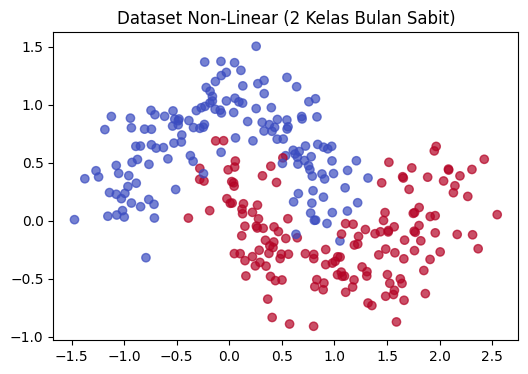

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

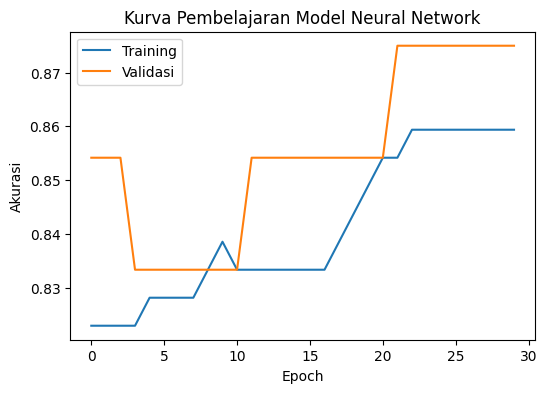

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =====================================================================
# LANGKAH 1: GENERATE DATASET NON-LINEAR (MAKE_MOONS)
# =====================================================================
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# =====================================================================
# LANGKAH 2: BANGUN & LATIH NEURAL NETWORK
# =====================================================================
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

# =====================================================================
# LANGKAH 3: EVALUASI & KURVA BELAJAR
# =====================================================================
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'\nAkurasi pada data uji: {acc:.3f}')

plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model Neural Network')
plt.show()

### Analisis Kurva Pembelajaran (Neural Network):
* **Pola Kurva:** Akurasi *Training* dan *Validasi* sama-sama menunjukkan tren meningkat seiring bertambahnya *epoch*, mencapai puncak di kisaran akurasi ~86% (*training*) dan ~87.5% (*validasi*).
* **Indikasi Model:** Nilai akurasi validasi berada di atas atau sejajar dengan akurasi *training* tanpa adanya celah (*gap*) penurunan pada kurva validasi. Hal ini menandakan bahwa model **fit dengan baik (good fit)**, terhindar dari *overfitting*, dan mampu mengenali pola non-linear dari *dataset make_moons* secara efektif.

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# =====================================================================
# LANGKAH 4: SIAPKAN DATASET ULASAN PRODUK (40 ULASAN)
# =====================================================================
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi', 'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas', 'Buruk sekali, tidak sesuai ekspektasi',
    'Produk original dan berfungsi dengan baik', 'Penjual tidak ramah, respon sangat lambat',
    'Packing rapi dan aman sampai tujuan', 'Bahan tipis dan gampang robek',
    'Sangat bagus, respon penjual cepat', 'Barang KW, menyesal beli di sini',
    'Pengiriman kilat, mantap betul', 'Lama banget sampai, kurir tidak sopan',
    'Kualitas mantap, sesuai harga', 'Pengiriman terlambat, barang penyok',
    'Pelayanan toko sangat memuaskan', 'Kecewa berat, barang tidak bisa dipakai',
    'Top banget, tidak ada cacat', 'Sangat mengecewakan, seller penipu',
    'Sesuai deskripsi, mantap', 'Kualitas buruk, jangan beli di sini',
    'Produk bekerja dengan sempurna', 'Pengiriman lelet, komplain tidak direspon',
    'Bintang lima untuk kualitas barang', 'Barang datang tidak lengkap',
    'Pengemasan super aman, terima kasih', 'Sangat lambat, tidak recommended',
    'Amanah banget tokonya, sukses terus', 'Barang pecah, packing jelek',
    'Sangat sesuai dengan gambar', 'Material jelek dan bau menyengat',
    'Sangat direkomendasikan, mantap', 'Respon penjual buruk sekali',
    'Kualitas terbaik di harganya', 'Barang bekas, bukan baru',
    'Produk sampai tanpa cacat sedikitpun', 'Layanan mengecewakan, rugi beli',
    'Puas banget belanja di sini', 'Sangat menyesal, barang cepat rusak'
]

# Label: 1 = Positif, 0 = Negatif
label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# =====================================================================
# LANGKAH 5: UBAH TEKS MENJADI REPRESETASI TF-IDF
# =====================================================================
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('=== Ekstraksi Fitur Teks (TF-IDF) ===')
print('Jumlah kata unik (Vocab):', len(tfidf.get_feature_names_out()))
print('Contoh 10 kata unik pertama:', tfidf.get_feature_names_out()[:10])

# =====================================================================
# LANGKAH 6: LATIH MODEL KLASIFIKASI SENTIMEN & EVALUASI
# =====================================================================
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print('\n=== Evaluasi Model Sentimen ===')
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Pengujian dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print('\nHasil Prediksi Kalimat Baru:')
print(f'Teks: "{kalimat_baru[0]}"')
print('Hasil Sentimen:', 'Positif' if pred[0] == 1 else 'Negatif')

=== Ekstraksi Fitur Teks (TF-IDF) ===
Jumlah kata unik (Vocab): 102
Contoh 10 kata unik pertama: ['ada' 'akan' 'aman' 'amanah' 'bagus' 'bahan' 'baik' 'banget' 'barang'
 'barangnya']

=== Evaluasi Model Sentimen ===
Akurasi model sentimen: 0.875

Hasil Prediksi Kalimat Baru:
Teks: "Pelayanan sangat memuaskan dan ramah"
Hasil Sentimen: Positif


## Kesimpulan

* **Apa yang Dipelajari:** Memahami penerapan *Neural Network* (Layer *Dense*, aktivasi *ReLU* & *Sigmoid*) untuk klasifikasi batas non-linear, serta alur kerja *Natural Language Processing* (NLP) menggunakan ekstraksi fitur *TF-IDF* dan *Logistic Regression*.
* **Temuan Utama:**
  1. Arsitektur *Neural Network* berhasil memisahkan *dataset* melengkung (*make_moons*) dengan tren pembelajaran yang stabil tanpa indikasi *overfitting*.
  2. Model *Logistic Regression* berbasis *TF-IDF* memproses **102 kata unik** dari dataset ulasan dan menghasilkan akurasi pengujian sebesar **87.5%**, serta sukses memprediksi kalimat baru *"Pelayanan sangat memuaskan dan ramah"* sebagai **Positif**.
* **Keterbatasan & Pertanyaan:**
  * *Keterbatasan:* Pendekatan *TF-IDF* tidak memperhitungkan urutan konteks kata (hanya frekuensi kata/bag-of-words), sehingga berpotensi gagal pada kalimat yang memiliki negasi kompleks atau sarkasme.
  * *Pertanyaan:* Bagaimana cara menerapkan arsitektur *Deep Learning* khusus teks seperti *Recurrent Neural Network* (RNN) atau *Transformer* (BERT) agar model dapat memahami urutan dan konteks makna kalimat secara lebih mendalam?